In [ ]:
!pip install gpytorch

In [2]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
dtype = torch.float64
torch.set_default_dtype(dtype)

Using device: cpu


In [4]:
#@title GT functions

def f1(x, A=1.0, tau=1.6, offset=0.05):
    """
    Monotonic increasing function with saturation.
    """
    return offset + A * (1.0 - np.exp(-x / tau))

def f2(x, L=1.0, x0=2.5, k=3.0, offset=0.05):
    """
    Sigmoid-like transition.
    """
    return offset + L / (1 + np.exp(-k * (x - x0)))

def f3(x, x0=2.5, gamma=0.25, A=1.0, offset=0.05):
    """
    Lorentzian resonance peak.
    """
    return offset + A * gamma**2 / ((x - x0)**2 + gamma**2)

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """
    Damped oscillatory response.
    """
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)

In [5]:
#@title auxilary functions

def generate_experiment_data(f_true, x_grid, n_points=9, noise_std=0.05, seed=None, plot=True):
    """
    Generate sparse noisy experimental observations from a ground truth function.

    Parameters
    ----------
    f_true : function
        Ground truth function f(x)
    x_grid : array
        Dense grid of x values
    n_train : int
        Number of experimental points
    noise_std : float
        Standard deviation of Gaussian noise
    seed : int or None
        Random seed for reproducibility
    plot : bool
        Whether to visualize the data

    Returns
    -------
    x_train, y_train
    """

    if seed is not None:
        np.random.seed(seed)

    idx = np.sort(np.random.choice(np.arange(len(x_grid)), size=n_points, replace=False))
    x_train = x_grid[idx]
    y_train = f_true(x_train) + np.random.normal(0, noise_std, size=n_points)

    if plot:
        plt.figure(figsize=(7,4))
        plt.plot(x_grid, f_true(x_grid), label="True function")
        plt.scatter(x_train, y_train, color="red", s=60, label="Observed points", zorder=3)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

    return x_train, y_train

In [6]:
#@title GP model

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if plot:
        plt.figure(figsize=(6, 3))
        plt.plot(losses)
        plt.xlabel("Iteration")
        plt.ylabel("Negative log marginal likelihood")
        plt.title("Training loss")
        plt.show()

    return losses

# Hackathon Task

The objective is to explore an alternative workflow for interpreting sparse experimental data using Gaussian Processes (GP).


Instead of relying solely on the most probable GP prediction (i.e., the posterior mean), we consider the following approach:

1. Fit a GP model to a small set of noisy observations.
2. Draw multiple candidate functions from the GP posterior (Thompson-style sampling).
3. Treat these sampled functions as plausible hypotheses consistent with the data.
4. Select the final candidate based on external criteria such as known physics, constraints, or expected qualitative behavior.


In this notebook we implement the first three steps of this workflow.
The goal of the hackathon is to develop possible realizations of Step 4:
designing criteria or algorithms for ranking and selecting the most meaningful prediction from the GP posterior.


**Please, do not forget to submit your result. A short YouTube tutorial from Utkarsh explaining how to submit your results:**
https://www.youtube.com/watch?v=QcwQkAocrDY&t=35s

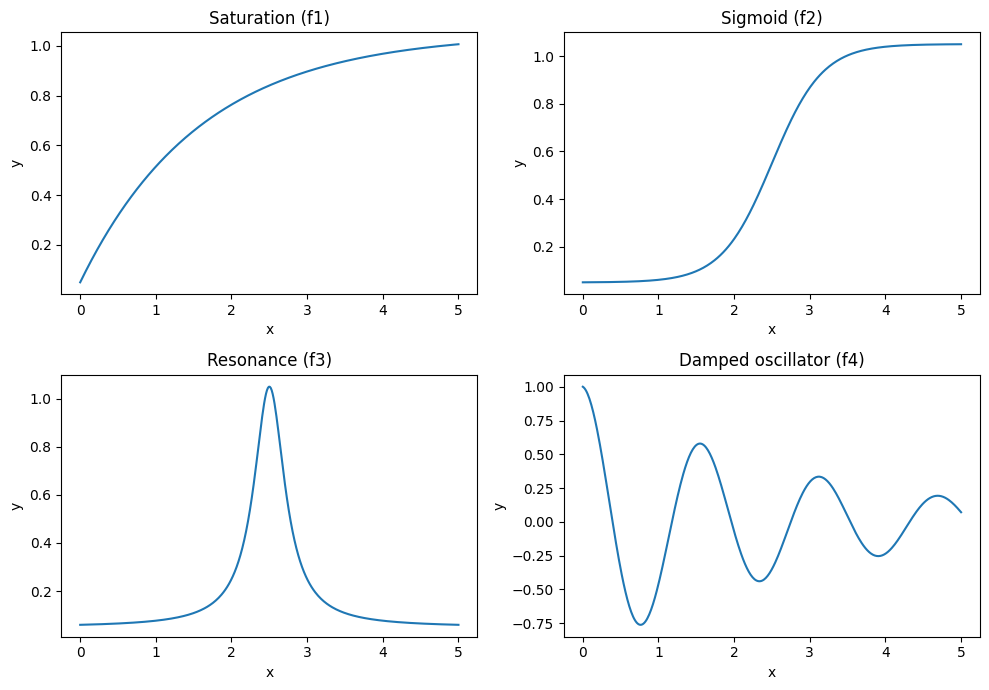

In [7]:
x_grid = np.linspace(0.0, 5.0, 400)
y1 = f1(x_grid)
y2 = f2(x_grid)
y3 = f3(x_grid)
y4 = f4(x_grid)

fig, ax = plt.subplots(2,2, figsize = (10,7))

for ax_ ,yy in zip(ax.flatten(), [y1, y2, y3, y4]):
  ax_.plot(x_grid, yy)
  ax_.set_xlabel("x")
  ax_.set_ylabel("y")

for ax_ ,ttl in zip(ax.flatten(), ['Saturation (f1)', 'Sigmoid (f2)', 'Resonance (f3)', 'Damped oscillator (f4)']):
  ax_.set_title(ttl)

plt.tight_layout()
# plt.show()

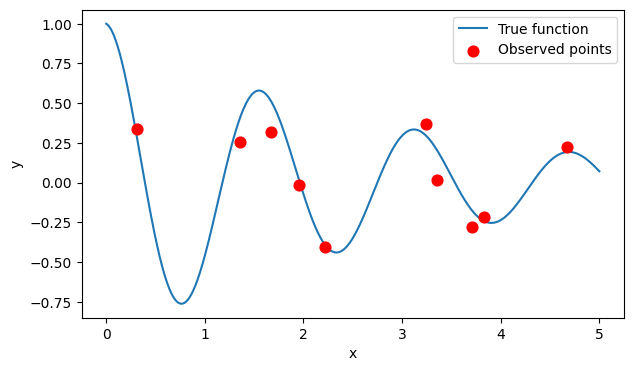

In [243]:
#choose function
f= f4

x_exp, y_exp = generate_experiment_data(f, x_grid, n_points=10, noise_std=0.1, seed=41)

#converting to torch.tensor
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

In [245]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

model = model.to(device=device, dtype=dtype)
likelihood = likelihood.to(device=device, dtype=dtype)



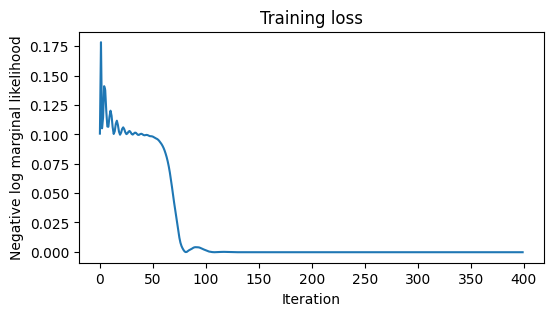

In [251]:
losses = train_gp(model, likelihood, train_x, train_y, lr=0.1, training_iter=400, plot=True)

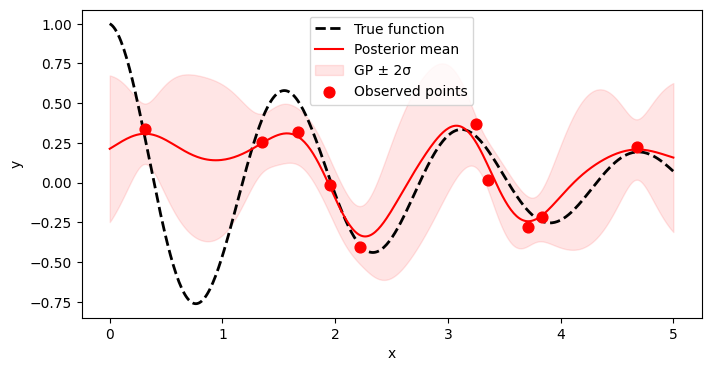

In [252]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_grid, f(x_grid), 'k--', label="True function", linewidth=2)
plt.plot(x_grid, pred_mean, 'r',label="Posterior mean", linestyle="-")
plt.fill_between(
    x_grid,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.1,
    label="GP ± 2σ",
    color='r'
)
plt.scatter(x_exp, y_exp, color="red", s=60, label="Observed points", zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [253]:
#Tompson sampling

n_candidates = 64 #number of the cundidate functions

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

samples_np = samples.cpu().numpy() # - candidate function

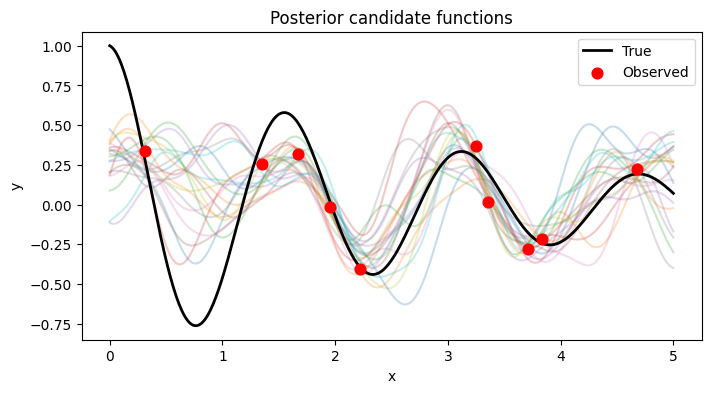

In [254]:
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 20)):
    plt.plot(x_grid, samples_np[i], alpha=0.25)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

# Can we design criteria or algorithms for ranking and selecting the most meaningful candidate function?

Option 2: Cluster-then-pick-prototype

This is also very general.

Procedure:

sample many posterior functions

compute pairwise distances between them

cluster them in function space

find the dominant cluster

choose the most central member of that cluster

Generate posterior samples

In [255]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [256]:
# Step 1: draw posterior samples
n_candidates = 200

model.eval()
likelihood.eval()

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))
    pred_mean = posterior.mean.cpu().numpy()

samples_np = samples.cpu().numpy()   # shape: (n_candidates, len(x_grid))

print("samples_np shape:", samples_np.shape)


samples_np shape: (200, 400)


Visualize the sampled hypotheses

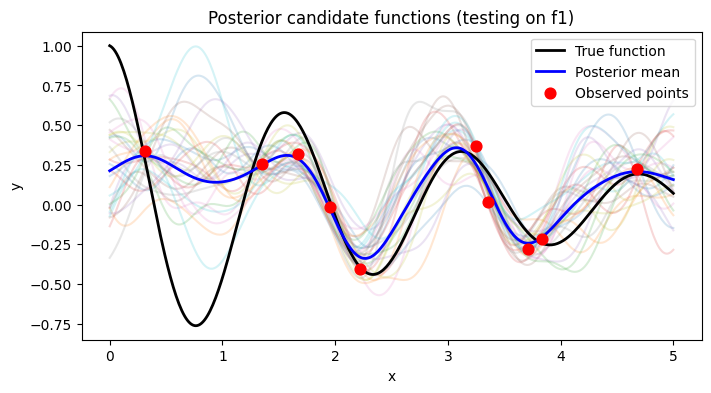

In [257]:
# Step 2: visualize posterior samples
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 30)):
    plt.plot(x_grid, samples_np[i], alpha=0.18)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True function")
plt.plot(x_grid, pred_mean, color="blue", linewidth=2, label="Posterior mean")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions (testing on f1)")
plt.legend()
plt.show()


Compute pairwise distances between sampled functions

Instead of clustering only on raw function values, we compare both:

the function itself

its slope

That usually gives better shape-based clustering.

In [258]:
# Step 3: pairwise distance using values + derivatives
def pairwise_function_distances(samples_np, x_grid, alpha=1.0, beta=0.2):
    """
    Pairwise distance using both function values and first derivatives.

    D(i,j) = alpha * MSE(values) + beta * MSE(derivatives)
    """
    n = samples_np.shape[0]
    D = np.zeros((n, n))
    dx = x_grid[1] - x_grid[0]

    derivs = np.gradient(samples_np, dx, axis=1)

    for i in range(n):
        for j in range(i + 1, n):
            d_val = np.mean((samples_np[i] - samples_np[j])**2)
            d_der = np.mean((derivs[i] - derivs[j])**2)
            d = alpha * d_val + beta * d_der
            D[i, j] = d
            D[j, i] = d

    return D

D = pairwise_function_distances(samples_np, x_grid, alpha=1.0, beta=0.2)
print("Distance matrix shape:", D.shape)


Distance matrix shape: (200, 200)


Cluster the sampled functions

automatic choice of number of clusters

In [259]:
# Step 4: choose best number of clusters automatically
def choose_best_k(D, k_list=(2, 3, 4, 5, 6, 7, 8, 9, 10)):
    best_k = None
    best_score = -np.inf
    best_labels = None

    for k in k_list:
        labels = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage="average"
        ).fit_predict(D)

        score = silhouette_score(D, labels, metric="precomputed")
        print(f"k={k}, silhouette={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_k, best_score, best_labels

best_k, best_silhouette, cluster_labels = choose_best_k(D, k_list=(2, 3, 4, 5, 6))

print("\nSelected number of clusters:", best_k)
print("Best silhouette score:", best_silhouette)
print("Cluster sizes:", np.bincount(cluster_labels))


k=2, silhouette=0.3322
k=3, silhouette=0.2220
k=4, silhouette=0.1393
k=5, silhouette=0.1132
k=6, silhouette=0.0963

Selected number of clusters: 2
Best silhouette score: 0.3322378902036067
Cluster sizes: [199   1]


In [260]:
# manual k selection


best_k = 10
best_silhouette = None

cluster_labels = AgglomerativeClustering(
    n_clusters=best_k,
    metric="precomputed",
    linkage="average"
).fit_predict(D)

In [261]:
# Step 5: helper functions
def candidate_fit_error(y_candidate, x_grid, x_obs, y_obs):
    """
    Interpolate candidate at observed x positions and compute MSE.
    """
    y_interp = np.interp(x_obs, x_grid, y_candidate)
    return np.mean((y_interp - y_obs)**2)

def cluster_compactness(D, cluster_indices):
    """
    Average pairwise distance within a cluster.
    Lower means more compact.
    """
    if len(cluster_indices) <= 1:
        return 0.0
    subD = D[np.ix_(cluster_indices, cluster_indices)]
    iu = np.triu_indices_from(subD, k=1)
    return np.mean(subD[iu])

def cluster_mean_fit(samples_np, cluster_indices, x_grid, x_obs, y_obs):
    """
    Mean fit error of members in a cluster.
    Lower is better.
    """
    errs = [
        candidate_fit_error(samples_np[i], x_grid, x_obs, y_obs)
        for i in cluster_indices
    ]
    return np.mean(errs)


In [262]:
# Step 6: score clusters using multiple criteria
def choose_best_cluster(cluster_labels, D, samples_np, x_grid, x_obs, y_obs,
                        w_size=1.0, w_compact=1.0, w_fit=1.0):
    """
    Score each cluster using:
    + size
    - compactness
    - mean fit error
    """
    unique_clusters = np.unique(cluster_labels)

    rows = []
    for c in unique_clusters:
        idx = np.where(cluster_labels == c)[0]
        size = len(idx)
        compact = cluster_compactness(D, idx)
        fit = cluster_mean_fit(samples_np, idx, x_grid, x_obs, y_obs)

        rows.append({
            "cluster": c,
            "size": size,
            "compactness": compact,
            "mean_fit_error": fit
        })

    df = pd.DataFrame(rows)

    # normalize
    df["size_norm"] = (df["size"] - df["size"].mean()) / (df["size"].std() + 1e-12)
    df["compact_norm"] = (df["compactness"] - df["compactness"].mean()) / (df["compactness"].std() + 1e-12)
    df["fit_norm"] = (df["mean_fit_error"] - df["mean_fit_error"].mean()) / (df["mean_fit_error"].std() + 1e-12)

    # higher is better
    df["cluster_score"] = (
        + w_size * df["size_norm"]
        - w_compact * df["compact_norm"]
        - w_fit * df["fit_norm"]
    )

    best_row = df.sort_values("cluster_score", ascending=False).iloc[0]
    best_cluster = int(best_row["cluster"])

    return best_cluster, df.sort_values("cluster_score", ascending=False).reset_index(drop=True)

best_cluster, df_cluster_scores = choose_best_cluster(
    cluster_labels, D, samples_np, x_grid, x_exp, y_exp,
    w_size=1.0, w_compact=1.0, w_fit=1.0
)

print("Selected cluster:", best_cluster)
display(df_cluster_scores)


Selected cluster: 0


,cluster,size,compactness,mean_fit_error,size_norm,compact_norm,fit_norm,cluster_score
0,0,179,0.233323,0.009892,2.844430,1.115813,-1.051660,2.780277
1,8,1,0.000000,0.012794,-0.339900,-1.127955,-0.210043,0.998097
2,1,4,0.206538,0.008801,-0.286232,0.858233,-1.367863,0.223398
3,7,1,0.000000,0.016485,-0.339900,-1.127955,0.859966,-0.071912
4,5,1,0.000000,0.016701,-0.339900,-1.127955,0.922501,-0.134447
5,9,2,0.154993,0.011827,-0.322011,0.362548,-0.490585,-0.193974
6,4,7,0.173636,0.011660,-0.232563,0.541828,-0.539063,-0.235328
7,2,2,0.171878,0.013750,-0.322011,0.524926,0.066894,-0.913831
8,6,1,0.000000,0.020270,-0.339900,-1.127955,1.957251,-1.169197
9,3,2,0.232559,0.013010,-0.322011,1.108470,-0.147397,-1.283084


Find the dominant cluster

choose the final prototype using centrality + fit

This is upgrade (4).

Inside the chosen cluster, we do not use pure medoid anymore.
We use:

centrality: close to other cluster members

fit: agrees with observed data

In [263]:
# Step 7: select prototype using centrality + fit
def choose_cluster_prototype(cluster_indices, D, samples_np, x_grid, x_obs, y_obs,
                             w_central=1.0, w_fit=1.0):
    """
    Prototype score inside a cluster:
    - low average distance to other members
    - low fit error on observed points
    """
    rows = []

    for idx in cluster_indices:
        centrality = D[idx, cluster_indices].mean()
        fit_err = candidate_fit_error(samples_np[idx], x_grid, x_obs, y_obs)

        rows.append({
            "candidate": idx,
            "centrality": centrality,
            "fit_error": fit_err
        })

    df = pd.DataFrame(rows)

    # normalize
    df["centrality_norm"] = (df["centrality"] - df["centrality"].mean()) / (df["centrality"].std() + 1e-12)
    df["fit_norm"] = (df["fit_error"] - df["fit_error"].mean()) / (df["fit_error"].std() + 1e-12)

    # lower centrality and lower fit error are better
    df["prototype_score"] = -(
        w_central * df["centrality_norm"] +
        w_fit * df["fit_norm"]
    )

    best_row = df.sort_values("prototype_score", ascending=False).iloc[0]
    prototype_idx = int(best_row["candidate"])

    return prototype_idx, df.sort_values("prototype_score", ascending=False).reset_index(drop=True)

best_cluster_indices = np.where(cluster_labels == best_cluster)[0]

prototype_idx, df_prototype_scores = choose_cluster_prototype(
    best_cluster_indices, D, samples_np, x_grid, x_exp, y_exp,
    w_central=1.0, w_fit=1.0
)

prototype_sample = samples_np[prototype_idx]

print("Prototype index:", prototype_idx)
display(df_prototype_scores.head(10))


Prototype index: 107


,candidate,centrality,fit_error,centrality_norm,fit_norm,prototype_score
0,107,0.167965,0.003705,-1.525980,-1.437983,2.963963
1,121,0.170626,0.005178,-1.462593,-1.095630,2.558223
2,72,0.154822,0.006954,-1.839088,-0.682706,2.521793
3,177,0.191160,0.003231,-0.973393,-1.548022,2.521415
4,75,0.192796,0.003150,-0.934421,-1.567011,2.501432
5,190,0.186278,0.004190,-1.089700,-1.325211,2.414911
6,76,0.166391,0.006614,-1.563470,-0.761870,2.325340
7,47,0.170136,0.006407,-1.474258,-0.809810,2.284069
8,31,0.165620,0.007186,-1.581852,-0.628791,2.210643
9,9,0.171496,0.006807,-1.441857,-0.716902,2.158758


Plot the dominant cluster and selected prototype

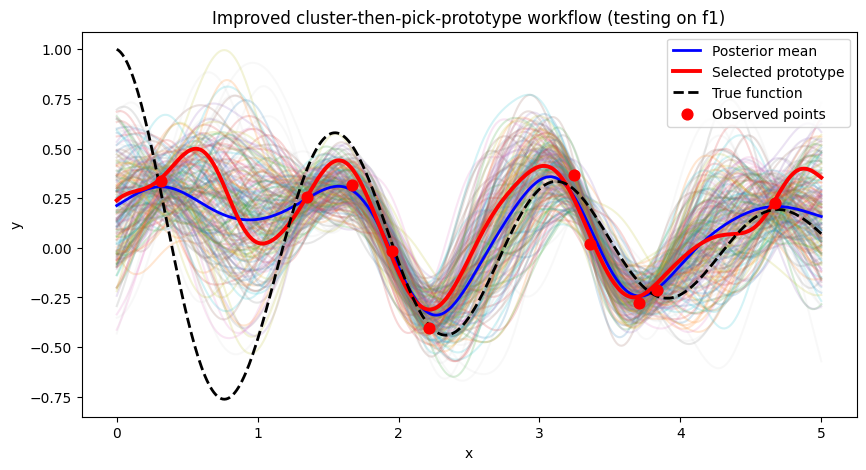

In [264]:
# Step 8: visualize selected cluster and prototype
plt.figure(figsize=(10, 5))

for i in range(samples_np.shape[0]):
    if cluster_labels[i] == best_cluster:
        plt.plot(x_grid, samples_np[i], alpha=0.18)
    else:
        plt.plot(x_grid, samples_np[i], color="gray", alpha=0.05)

plt.plot(x_grid, pred_mean, color="blue", linewidth=2, label="Posterior mean")
plt.plot(x_grid, prototype_sample, color="red", linewidth=2.8, label="Selected prototype")
plt.plot(x_grid, f(x_grid), "k--", linewidth=2, label="True function")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Improved cluster-then-pick-prototype workflow (testing on f1)")
plt.legend()
plt.show()


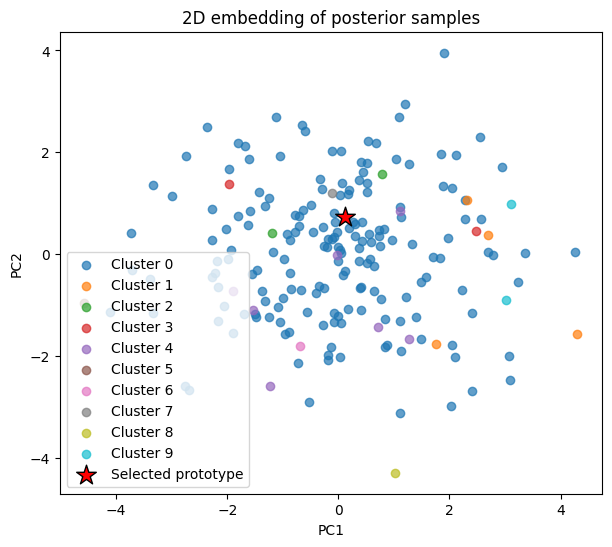

In [265]:
# Step 9: 2D embedding for visualization
X_2d = PCA(n_components=2).fit_transform(samples_np)

plt.figure(figsize=(7, 6))
for c in np.unique(cluster_labels):
    idx = np.where(cluster_labels == c)[0]
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], alpha=0.7, label=f"Cluster {c}")

plt.scatter(
    X_2d[prototype_idx, 0],
    X_2d[prototype_idx, 1],
    s=220,
    marker="*",
    color="red",
    edgecolor="black",
    label="Selected prototype"
)

plt.title("2D embedding of posterior samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


Compare against posterior mean

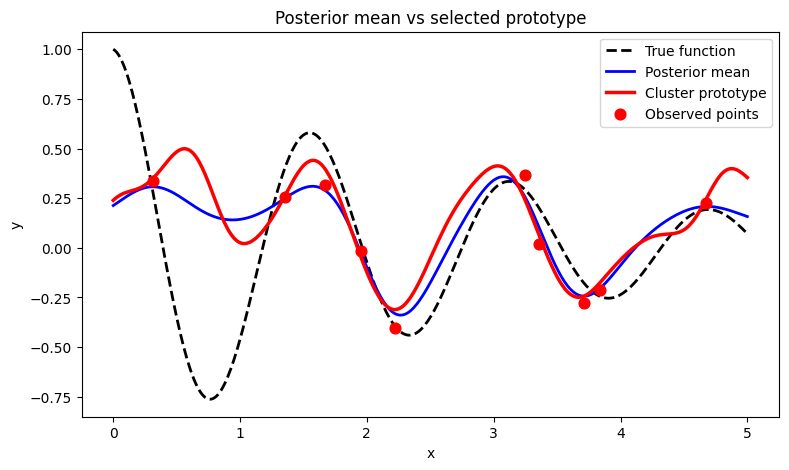

In [266]:
# Step 8: compare prototype with posterior mean
with torch.no_grad():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()

plt.figure(figsize=(9, 5))
plt.plot(x_grid, f(x_grid), "k--", linewidth=2, label="True function")
plt.plot(x_grid, pred_mean, color="blue", linewidth=2, label="Posterior mean")
plt.plot(x_grid, prototype_sample, color="red", linewidth=2.5, label="Cluster prototype")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior mean vs selected prototype")
plt.legend()
plt.show()


Inspect cluster sizes and optionally plot clusters separately

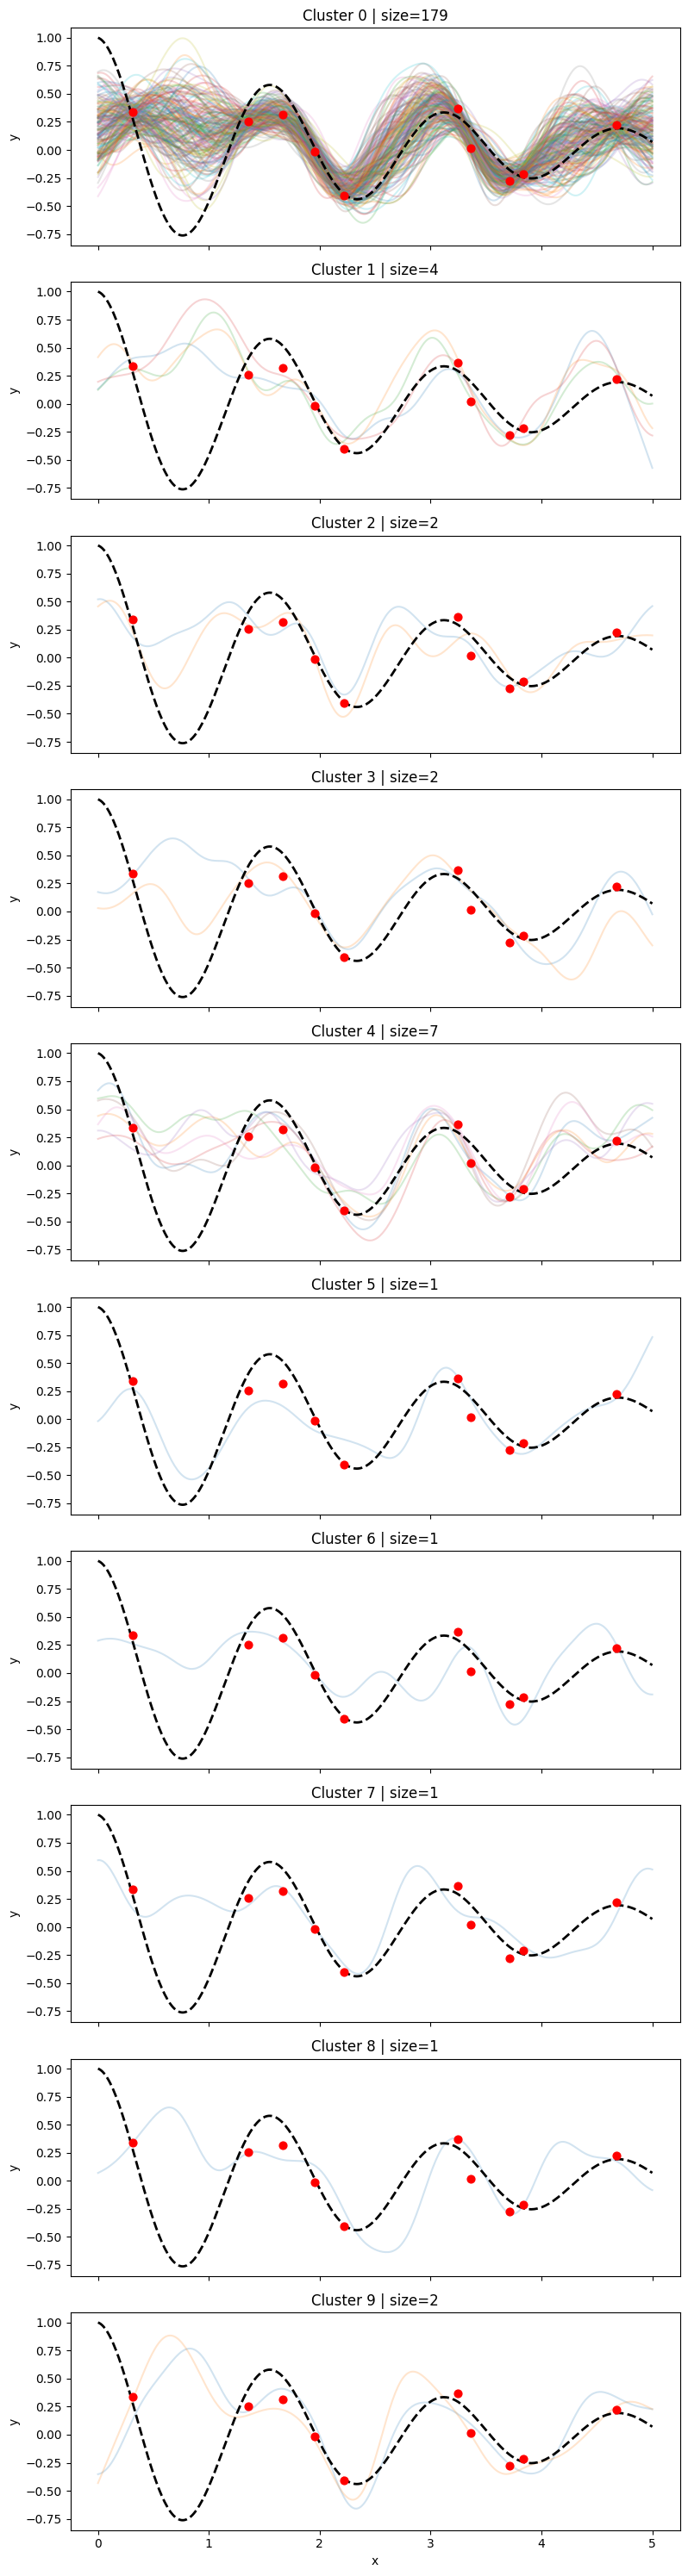

In [267]:
# Step 9: inspect all clusters
unique_clusters = np.unique(cluster_labels)

fig, axes = plt.subplots(len(unique_clusters), 1, figsize=(8, 3 * len(unique_clusters)), sharex=True)

if len(unique_clusters) == 1:
    axes = [axes]

for ax, c in zip(axes, unique_clusters):
    idx = np.where(cluster_labels == c)[0]
    for i in idx:
        ax.plot(x_grid, samples_np[i], alpha=0.2)
    ax.plot(x_grid, f(x_grid), "k--", linewidth=2)
    ax.scatter(x_exp, y_exp, color="red", s=40, zorder=3)
    ax.set_title(f"Cluster {c} | size={len(idx)}")
    ax.set_ylabel("y")

axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()


<font color = "teal" size  =6>**Posterior mean**<font>

That means it is not necessarily an actual plausible hypothesis by itself in a structural sense. It is just the expectation.

This often causes:

smoothing out sharp features

blending together different modes of behavior

producing a curve that no actual posterior sample looks like

<font color = "tomato" size= 6>**Cluster-then-pick-prototype**<font>

So instead of averaging all candidates together, it:

keeps each posterior sample as a complete hypothesis

groups similar hypotheses

finds the dominant mode

returns one actual sampled function from that mode

That means the output is:

an actual posterior-consistent curve

representative of one coherent family of explanations

less likely to be a blurred compromise